# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Hemen | Samadi | Hemen Samadi, Nov. 25, 2025 | 8 | 25% |
| Member 2: | Hannah | Horvath | Hannah Horvath, Nov. 25, 2025 | 8 | 25% |
| Member 3: | Hallie | Horvath | Hallie Horvath, Nov. 25, 2025 | 8 | 25% |
| Member 4: | Faizan | Mahmood | Faizan Mahmood, Nov. 25, 2025 | 8 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

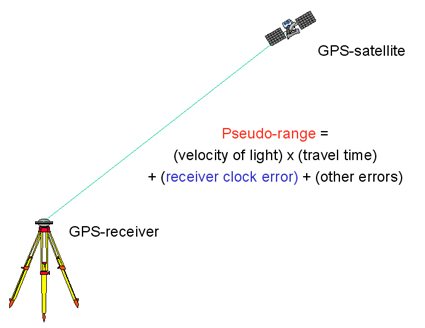

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
df_pseudorange = pd.read_excel("pseudoranges.xlsx")
df_pseudorange = df_pseudorange.drop(df_pseudorange.columns[0], axis=1)

df_sat_pos = pd.read_excel("satellite_position.xlsx")
df_sat_pos = df_sat_pos.drop(df_sat_pos.columns[0], axis=1)

# Convert to numpy arrays
pseudorange = df_pseudorange.to_numpy()
sat_pos = df_sat_pos.to_numpy()

np.random.seed(42)  # For reproducible results
pseudorange = pseudorange + np.random.uniform(0, 0.5, size=pseudorange.shape)


In [ ]:
sat_pos

array([[  5280791.73836563, -25501460.1192133 ,   4649508.28809917],
       [ -2159656.05205653, -21116024.7920163 ,  15597909.1971221 ],
       [ 10371852.1682927 , -21713111.3497771 ,  10558686.998121  ],
       [-16085760.7811889 ,   4285071.21612309,  20742042.1246963 ],
       [-14312988.0806279 , -22045014.2659254 ,   4671208.3988653 ],
       [ -2435718.18737303,  16257205.12951   ,  21099779.5379103 ],
       [ 15912467.1868696 ,  -3462515.31492602,  21053628.253335  ],
       [ 16271848.163885  ,   -218766.32031082,  21035332.7037679 ],
       [-19247035.5286677 ,  -7259803.67892242,  16472981.9071979 ],
       [-15931152.0364578 ,  12077367.2515846 ,  18058076.7648504 ],
       [ -7680014.10843999, -13855462.7231353 ,  21842975.3728112 ]])

In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]
print(f"The number of the measurements are {n}")

m= 4
print(f"The number of the unknown stares are {m}")


The number of the measurements are 11
The number of the unknown stares are 4


In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    distance = np.linalg.norm(satellite_pos - receiver_pos, axis=1)

    return distance


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
variance = 1.2
# n=the number of measurements
P = (1/variance) * np.eye(n)

P

array([[0.83333333, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.83333333, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.83333333, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.83333333, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.83333333,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.83333333, 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])
x_0

array([ 100.,  -50.,   25., 1000.])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
delta = np.full(4, 10.0)   # corrections array of size 4, all initialized to 10s
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = []

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
def design_matrix(receiver_pos, satellite_pos, distance):

    # Differences between receiver and satellites
    diff = receiver_pos - satellite_pos

    # Euclidean distances
    ##rho = np.sqrt(np.sum(diff**2, axis=1))

    # Partial derivatives: (r - s) / rho
    partials = diff / distance[:, np.newaxis]

    # Append the clock bias column (-1)
    A = np.hstack((partials, -np.ones((satellite_pos.shape[0], 1))))

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:
while np.any(np.abs(delta[:3]) > 0.008):

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(x_0[:3], sat_pos)


       # compute the design matrix A
       # (0.5 marks)
       A =  design_matrix(x_0[:3], sat_pos, distance)


       # compute the misclosure array w
       # (0.5 marks)
       w = pseudorange.flatten() - (distance + x_0[3])

       # compute the corrections delta
       # (0.5 marks)
       N = A.T @ P @ A
       u = A.T @ P @ w
       delta = np.linalg.inv(N) @ u

       # update the states
       x_0 = x_0 + delta


       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = np.linalg.norm(x_0[:3] - GroundTruth)


       # update the counter i, (i.e., increament of 1 for each iteration)
       i += 1

       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(w)
       arr_delta.append(delta)
       arr_err_pos.append(err_pos)
       arr_i.append(i)


# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
v = w - A @ delta
apv = apv = (v.T @ P @ v) / (len(pseudorange) - len(x_0))

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = np.linalg.inv(A.T @ P @ A)
x_hat = x_0

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
print(f"\nEstimated states: {x_hat}")
print(f"Corrections array (last iteration): {delta}") # Note: delta here is the last correction applied before convergence
print(f"Estimated measurements residuals (v): {v}")
print(f"A Posteriori Variance of Unit Weight: {apv}")
print(f"Covariance matrix of estimated states:\n{C_x_hat}")
print(f"Number of iterations: {i}")
print(f"3-D position error: {err_pos}")


Estimated states: [ -1633492.4560264   -3651629.53333912   4952485.42072981
 -19935384.73474048]
Corrections array (last iteration): [ 3.23820859e-06  6.42985106e-06 -1.77621841e-05 -9.96769572e+06]
Estimated measurements residuals (v): [ 0.2048478   0.34241078 -0.98042663  0.06600715  0.04710038 -1.57078689
 -0.30919804  1.6995891   0.33525003  0.74095414 -0.57574789]
A Posteriori Variance of Unit Weight: 0.9013677110167452
Covariance matrix of estimated states:
[[ 0.38358008  0.08359494 -0.10148642  0.08768258]
 [ 0.08359494  0.51056248 -0.69728578  0.44191032]
 [-0.10148642 -0.69728578  2.45472191 -1.32482481]
 [ 0.08768258  0.44191032 -1.32482481  0.83910884]]
Number of iterations: 5
3-D position error: 5.425801850527041


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

**A posteriori variance of unit weight**

The value is 0.901, which is close to 1. This suggests the residuals are broadly consistent with the assumed measurement noise model, with a slight indication that the observation variances may be a bit conservative (overestimated), or the fit is marginally better than expected. In short, the solution is well-tuned and not overfitting.

**Covariance matrix of estimated states**


the covariance matrix shows good precision for some states, but strong correlations (especially between 3 and 4) highlight limited independence and potential instability in those estimates. The solution is reliable for States 1–2, but States 3 and 4 are highly coupled, making them less stable and more sensitive to measurement/model assumptions.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

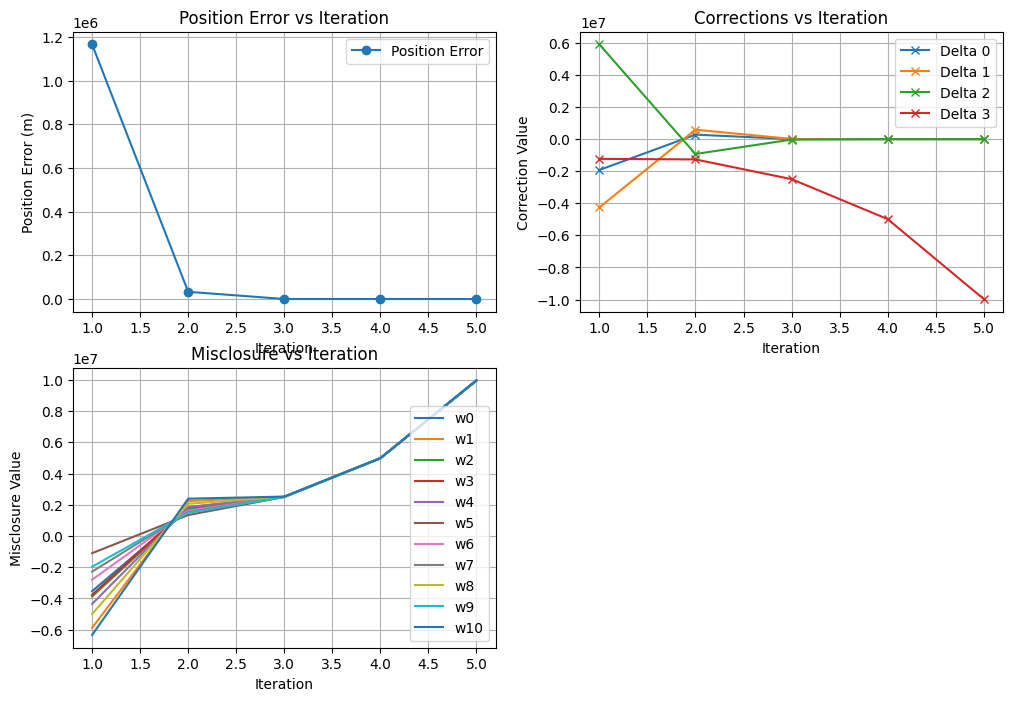

In [ ]:
import matplotlib.pyplot as plt

# Convert lists to numpy arrays for plotting
arr_delta_np = np.array(arr_delta)
arr_w_np = np.array(arr_w)

plt.figure(figsize=(12,8))

# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)

plt.subplot(2,2,1)
plt.plot(arr_i, arr_err_pos, marker='o', label='Position Error')
plt.xlabel('Iteration')
plt.ylabel('Position Error (m)')
plt.title('Position Error vs Iteration')
plt.grid(True)
plt.legend()

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
plt.subplot(2,2,2)
for j in range(arr_delta_np.shape[1]):
    plt.plot(arr_i, arr_delta_np[:,j], marker='x', label=f'Delta {j}')
plt.xlabel('Iteration')
plt.ylabel('Correction Value')
plt.title('Corrections vs Iteration')
plt.grid(True)
plt.legend()

# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)
plt.subplot(2,2,3)
for j in range(arr_w_np.shape[1]):
    plt.plot(arr_i, arr_w_np[:,j], label=f'w{j}')
plt.xlabel('Iteration')
plt.ylabel('Misclosure Value')
plt.title('Misclosure vs Iteration')
plt.grid(True)
plt.legend()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

***1. Position Error vs. Iteration:**
* The error between the estimated position and the ground truth decreases steadily. It shows a sharp drop in the first iteration, then flattens out once the solution is close to the true position.

***2. Corrections vs. Iteration:**
* The corrections for x, y, z start large (initialized at 10 m) and decrease gradually. They drop by orders of magnitude and stabilize near zero after a few iterations.


***3. Misclosure vs. Iteration:**
* The misclosure values (residuals) start relatively large and then reduce as the iterations progressThey oscillate slightly but converge toward small values near zero.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## ***It show as "High Level" in Northern Alberta.***

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
def euclidean_norm(receiver_pos, satellite_pos):
    receiver_pos = np.array(receiver_pos, dtype=np.float64)
    satellite_pos = np.array(satellite_pos, dtype=np.float64)
    if satellite_pos.ndim == 1:
        diff = satellite_pos - receiver_pos
        distance = np.linalg.norm(diff)
    else:
        diff = satellite_pos - receiver_pos
        distance = np.linalg.norm(diff, axis=1)
    return distance

In [ ]:
def design_matrix(receiver_pos, sat_pos, distance):
  n = sat_pos.shape[0]
  A = np.zeros((n, 4))
  for i in range(n):

    A[i, 0:3] = (receiver_pos - sat_pos[i]) / distance[i]
    A[i, 3] = -1.0
  return A

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):

    # Predicted pseudoranges = geometric distances - clock offset (P = rho - cdT)
    # Calculate all geometric distances at once
    geometric_distances = euclidean_norm(rec_pos, sat_pos)

    # Model P = rho - cdT, so predicted_P = geometric_distance - cdT
    predicted_ranges = geometric_distances - cdT

    # Residuals = observed - predicted
    # pseudorange is expected to be a 1D array here
    residuals = pseudorange - predicted_ranges

    # Sum of squared residuals
    L = np.sum(residuals**2)

    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    N = sat_pos.shape[0]

    # Calculate geometric distances for all satellites at once
    geometric_distances = euclidean_norm(rec_pos, sat_pos)

    # Initialize design matrix A (Jacobian of predicted_ranges with respect to X)
    A = np.zeros((N, 4))

    # Fill the first three columns of A (partial derivatives w.r.t. x_r, y_r, z_r)
    # d(rho)/dx_r = (x_r - s_x) / rho, etc.
    diff_coords = rec_pos - sat_pos  # (N, 3) array of (r_x-s_x, r_y-s_y, r_z-s_z)
    A[:, :3] = diff_coords / geometric_distances[:, np.newaxis]

    # Fill the last column of A (partial derivative w.r.t. cdT)
    # For model P = rho - cdT, d(predicted_P)/d(cdT) = -1
    A[:, 3] = -1.0

    # Predicted pseudoranges based on current estimates (P = rho - cdT)
    predicted_ranges = geometric_distances - cdT

    # Residuals = observed - predicted
    # pseudorange is expected to be a 1D array here
    residuals = pseudorange - predicted_ranges

    # Gradient of the cost function L = sum(residuals^2) is dL/dX = -2 * A.T @ residuals
    # (where A is dh/dX and residuals = obs - h(X))
    grad = -2 * A.T @ residuals

    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count
    # The line `sat_pos = sat_pos[:, 1:4]` was incorrect as the global `sat_pos`
    # (from df_sat_pos.to_numpy()) already contains only the [x,y,z] coordinates (N,3)
    # and should not be sliced further. This line has been removed.

    # Initialize the estimates for [x_r, y_r, z_r, cdT]
    X = np.array([50.0, -25.0, 15.0, 500.0], dtype=np.float64) # Ensure float64 for precision

    # Clear global arrays at the beginning of the function call
    global arr_cost, arr_grad, arr_err
    arr_cost = []
    arr_grad = []
    arr_err = []

    for iteration in range(max_iters):
        rec_pos = X[:3] # Current receiver position estimate
        cdT = X[3]      # Current clock offset estimate

        # Compute the cost in the current step
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # Compute the gradients in the current step
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)

        # Update estimates
        X_new = X - learning_rate * grad

        # Compute the new cost with updated estimates
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # Store intermediate results
        arr_cost.append(current_cost)
        arr_grad.append(np.linalg.norm(grad)) # Store norm of gradient for plotting
        # Store 3D position error (scalar magnitude)
        arr_err.append(np.linalg.norm(X[:3] - GroundTruth))

        # Check for convergence based on change in cost function
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count = iteration + 1 # +1 because iteration is 0-indexed
            # Append final values before breaking to ensure history includes the converged state
            arr_cost.append(new_cost)
            arr_grad.append(np.linalg.norm(gradient(X_new[:3], X_new[3], sat_pos, pseudorange))) # Recalculate grad for final X_new
            arr_err.append(np.linalg.norm(X_new[:3] - GroundTruth))
            X = X_new # Update X to the converged value
            break

        # Update the parameters for the next iteration
        X = X_new
    else:
        # This block executes if the loop completes without 'break' (i.e., max_iters reached)
        print("Maximum iterations reached without convergence.")
        steps_count = max_iters
        # Append final state if max_iters reached
        arr_cost.append(current_cost) # Last computed cost
        arr_grad.append(np.linalg.norm(grad)) # Last computed grad norm
        arr_err.append(np.linalg.norm(X[:3] - GroundTruth)) # Final position error

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
optimized_params = gradient_descent(pseudorange.flatten(), sat_pos)

# Assign global arrays to variables used in plotting cells
cost_history = arr_cost
grad_norms = arr_grad
pos_errors = arr_err

# print the mentioned metrics
print(f"Optimized Parameters: {optimized_params}")
print(f"Final Position Errors (3D norm): {np.linalg.norm(optimized_params[:3] - GroundTruth)}")
print(f"Number of Steps Taken for Convergence: {steps_count}")
print(f"Final Cost Value: {arr_cost[-1]}")
print(f"Final Gradient Values (norm): {arr_grad[-1]}")

Maximum iterations reached without convergence.
Optimized Parameters: [-1616184.59596918 -4389634.8224274   8306848.12640079 -6327556.24467303]
Final Position Errors (3D norm): 3434636.7194235995
Number of Steps Taken for Convergence: 10000
Final Cost Value: 275316478327536.12
Final Gradient Values (norm): 112186287.60915111


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

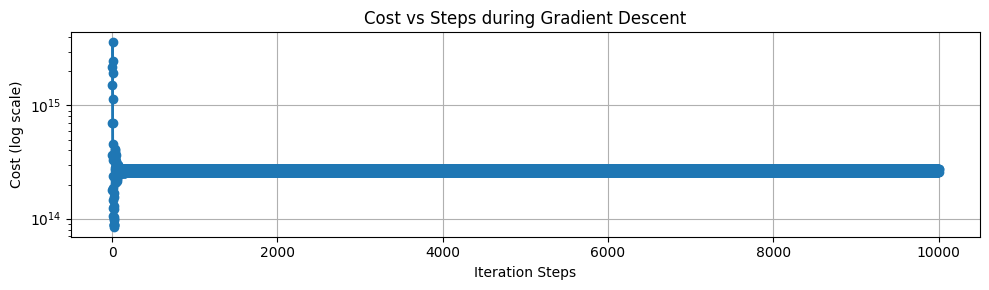

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# Plot cost vs iteration steps with logarithmic y-axis
ax.semilogy(range(len(cost_history)), cost_history, marker='o', linestyle='-')

# Label axes
ax.set_xlabel("Iteration Steps")
ax.set_ylabel("Cost (log scale)")

# Add title
ax.set_title("Cost vs Steps during Gradient Descent")

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# ...

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

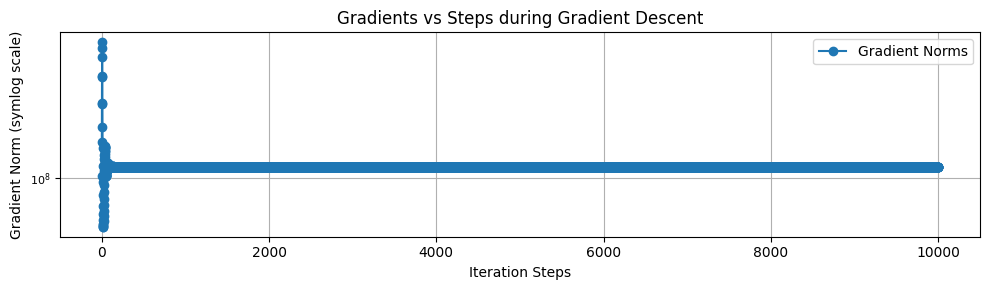

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# Plot gradient norms vs iteration steps with symlog scaling
ax.plot(range(len(grad_norms)), grad_norms, marker='o', linestyle='-', label="Gradient Norms")
ax.set_yscale('symlog')   # symmetric log scale for y-axis

# Label axes
ax.set_xlabel("Iteration Steps")
ax.set_ylabel("Gradient Norm (symlog scale)")

# Adjust tick label size
ax.tick_params(axis='y', labelsize=8)

# Add title and legend
ax.set_title("Gradients vs Steps during Gradient Descent")
ax.legend()


ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# ...

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

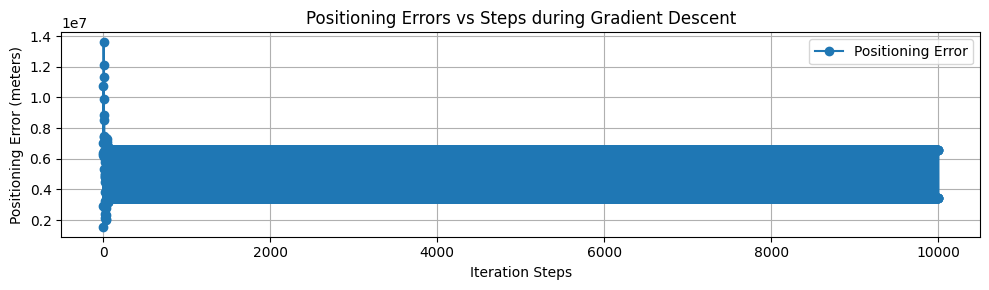

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)

# Plot positioning errors vs iteration steps
ax.plot(range(len(pos_errors)), pos_errors, marker='o', linestyle='-', label="Positioning Error")

# Label axes
ax.set_xlabel("Iteration Steps")
ax.set_ylabel("Positioning Error (meters)")

# Add title and legend
ax.set_title("Positioning Errors vs Steps during Gradient Descent")
ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# ...

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
learning_rate = 0.008

optimized_params_2 = gradient_descent(
    pseudorange.flatten(),
    sat_pos,
    learning_rate=learning_rate,
    max_iters=2000,
    tolerance=1e-6
)

# After the function call, you need to update cost_history_2 etc. from the global arrays
cost_history_2 = arr_cost
grad_norms_2 = arr_grad
pos_errors_2 = arr_err
steps_count_2 = steps_count

# print the metrics
rec_pos_opt_2 = optimized_params_2[:3]
cdT_opt_2 = optimized_params_2[3]
final_position_error_2 = rec_pos_opt_2 - GroundTruth

print("\n--- Learning Rate = 0.008 ---")
print("Optimized parameters:", optimized_params_2)
print("Final position errors:", final_position_error_2)
print("Final cost value:", cost_history_2[-1])

Maximum iterations reached without convergence.

--- Learning Rate = 0.008 ---
Optimized parameters: [-1.63348728e+06 -3.65160071e+06  4.95239683e+06  4.35207258e+01]
Final position errors: [  2.09668522  26.47309518 -84.78680599]
Final cost value: 3969.9309851228018


In [ ]:
#set learning rate to 0.0008
#re-initialize arrays and counters
global arr_cost, arr_grad, arr_err, steps_count # Declare as global to re-initialize
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

learning_rate = 0.0008
# (1 marks)
optimized_params_3 = gradient_descent(
    pseudorange.flatten(),
    sat_pos,
    learning_rate=learning_rate,
    max_iters=5000,   # allow more iterations for smaller step size
    tolerance=1e-6
)

# After the function call, update history variables from global arrays
cost_history_3 = arr_cost
grad_norms_3 = arr_grad
pos_errors_3 = arr_err
steps_count_3 = steps_count

# print the metrics
rec_pos_opt_3 = optimized_params_3[:3]
cdT_opt_3 = optimized_params_3[3]
final_position_error_3 = rec_pos_opt_3 - GroundTruth

print("\n--- Learning Rate = 0.0008 ---")
print("Optimized parameters:", optimized_params_3)
print("Final position errors:", final_position_error_3)
print("Final cost value:", cost_history_3[-1])

Maximum iterations reached without convergence.

--- Learning Rate = 0.0008 ---
Optimized parameters: [-1610935.15904251 -3527408.56233784  4571327.8194299    218401.26375037]
Final position errors: [  22554.22063474  124218.62016579 -381153.80011928]
Final cost value: 71291250218.97475


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


### Answers

**Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)**

A higher learning rate (0.008) allowed faster progress toward minimizing the cost, while the smaller learning rate (0.0008) caused underfitting and poor optimization due to insufficient updates.

**Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)**

LSE provides a closed-form solution, while gradient descent approximates the solution iteratively. Results show gradient descent's sensitivity to learning rate and iteration limits, unlike LSE which directly computes the optimal parameters.


---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=['id'])  # Remove irrelevant ID column
data.dropna()  # Remove rows with missing values
data.drop_duplicates()  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
data = data.drop(columns=['Age','Academic Pressure', 'Work Pressure' , 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress'])  # Remove irrelevant ID column



# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("Shape of dataset:", data.shape)

print(data.head())


Shape of dataset: (27901, 10)
   id  Gender           City Profession     Sleep Duration Dietary Habits  \
0   2    Male  Visakhapatnam    Student          5-6 hours        Healthy   
1   8  Female      Bangalore    Student          5-6 hours       Moderate   
2  26    Male       Srinagar    Student  Less than 5 hours        Healthy   
3  30  Female       Varanasi    Student          7-8 hours       Moderate   
4  32  Female         Jaipur    Student          5-6 hours       Moderate   

    Degree Have you ever had suicidal thoughts ?  \
0  B.Pharm                                   Yes   
1      BSc                                    No   
2       BA                                    No   
3      BCA                                   Yes   
4   M.Tech                                   Yes   

  Family History of Mental Illness  Depression  
0                               No           1  
1                              Yes           0  
2                              Yes           0 

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']
X = data.drop(columns=['Depression'])

# Display sizes of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (27901, 9)
Shape of y: (27901,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

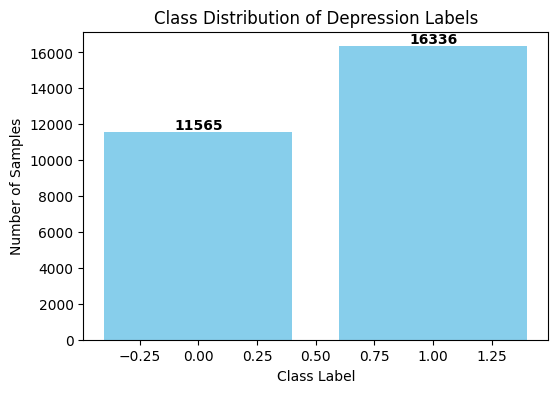

In [ ]:
# Check the class distribution of y
class_counts = y.value_counts()

# Plot histogram
plt.figure(figsize=(6,4))
bars = plt.bar(class_counts.index, class_counts.values, color='skyblue')

# Display exact values for each bin in the histogram
# hint: Use for loop
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Depression Labels")
plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(
    X, y,
    train_size=0.03,
    random_state=42,
)

# Display sizes of X_small and y_small (0.5 marks)
print("Shape of X_small:", X_small.shape)
print("Shape of y_small:", y_small.shape)

Shape of X_small: (837, 9)
Shape of y_small: (837,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(X, y, label):

    # Split dataset (70% train, 30% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0, stratify=y
    )

    # Fit model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    loss = log_loss(y_test, y_test_proba)

    # Add results to DataFrame
    results.loc[label] = [
        len(X),              # Data size
        len(X_train),        # Training samples
        len(X_test),         # Testing samples
        train_acc,           # Training accuracy
        test_acc,            # Testing accuracy
        loss                 # Log loss
    ]

    return X_train, X_test, y_train, y_test

# Test 1: Full dataset (X and y)
evaluate_model(X, y, "Full Dataset")

# Test 2: Only first two columns of X and y
evaluate_model(X.iloc[:, :2], y, "First two columns")

# Test 3: Small dataset (X_small and y_small)
evaluate_model(X_small, y_small, "Small dataset")

print(results)

                   Data size  Training samples  Testing samples  \
Full Dataset         27901.0           19530.0           8371.0   
First two columns    27901.0           19530.0           8371.0   
Small dataset          837.0             585.0            252.0   

                   Training accuracy  Testing accuracy  Log loss  
Full Dataset                0.784178          0.777565  0.513835  
First two columns           0.585509          0.585474  0.678467  
Small dataset               0.781197          0.777778  0.507189  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
X_train, X_test, y_train, y_test = evaluate_model(X, y, "Full Dataset")
y_pred = model.predict(X_test)

y_test_true = y_test
y_test_pred = model.predict(X_test)

print("True labels (y_test):")
print(y_test_true.values)

print("\nPredicted labels (y_pred):")
print(y_test_pred)

# Note: 70% training set, 30% testing set



True labels (y_test):
[0 0 1 ... 1 0 0]

Predicted labels (y_pred):
[1 1 0 ... 1 0 1]


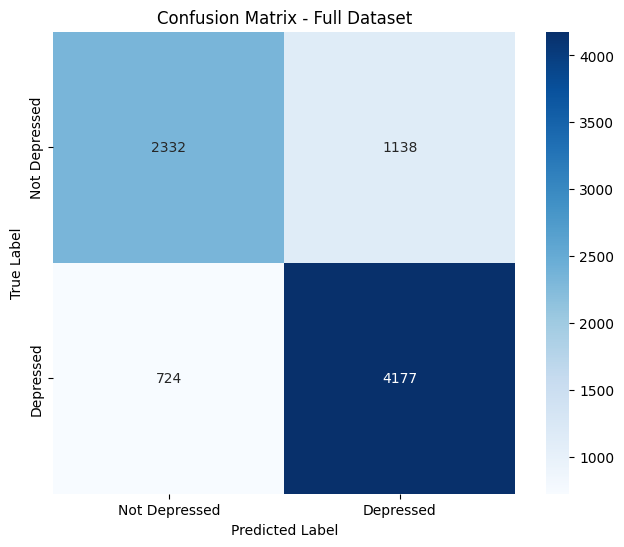

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
conf_mat = confusion_matrix(y_test, y_pred)



# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Full Dataset")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.67      0.71      3470
           1       0.79      0.85      0.82      4901

    accuracy                           0.78      8371
   macro avg       0.77      0.76      0.77      8371
weighted avg       0.78      0.78      0.78      8371



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=0),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train, y_train)

    # Make predictions
    y_pred = model_instance.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)

    # Print results
    print(f"{name} Accuracy: {acc:.4f}")



Logistic Regression Accuracy: 0.7776
Naive Bayes Accuracy: 0.6600
KNN Accuracy: 0.5320


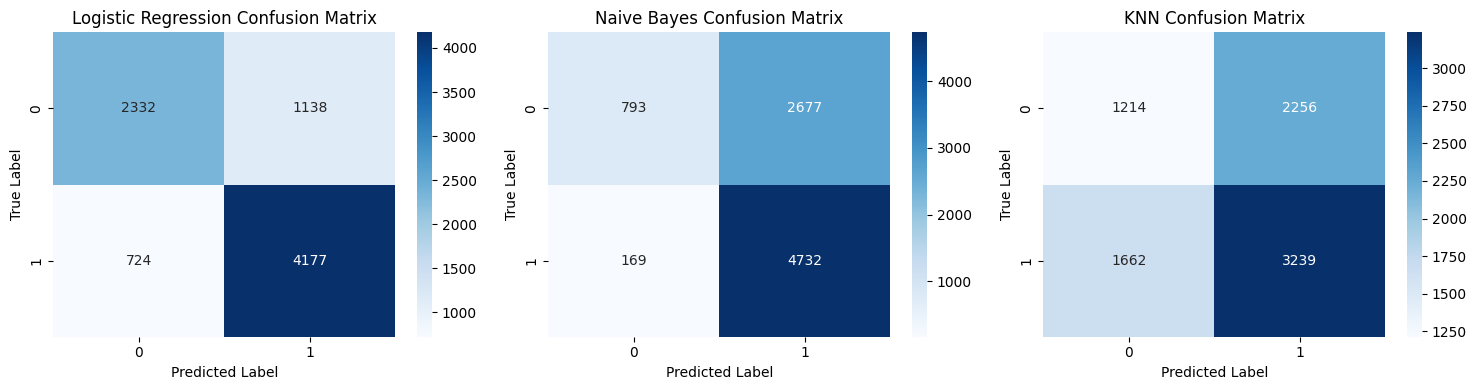

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

# Create confusion matrices for each model
plt.figure(figsize=(15,4))

for i, (name, model_instance) in enumerate(models.items(), 1):
    # Predictions on test set
    y_pred = model_instance.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model_instance.classes_,
                yticklabels=model_instance.classes_)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
# Print confusion matrices for all models
for name, model_instance in models.items():
    # Predictions on test set
    y_pred = model_instance.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Confusion Matrix:")
    print(cm)


Logistic Regression Confusion Matrix:
[[2332 1138]
 [ 724 4177]]

Naive Bayes Confusion Matrix:
[[ 793 2677]
 [ 169 4732]]

KNN Confusion Matrix:
[[1214 2256]
 [1662 3239]]


### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answers here

**1. Is the dataset balanced? Does it affect model performance? (1 mark)**

From the confusion matrices, the counts of positive vs. negative classes are not equal. This indicates class imbalance.

**2. Does the model overfit or underfit for each of the 3 cases? (1 marks)**

*Full dataset:* Logistic Regression shows reasonable balance between FP and FN which means not strongly overfitting.
*First two columns only:* Likely underfitting because fewer features reduce predictive power. Accuracy drops compared to full dataset.
*Small dataset (3%):* High variance due to limited data. Model may appear to fit training well but generalizes poorly.

**3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)**

*Full dataset:* Training accuracy is high, testing accuracy also strong.

*First two columns:* Both training and testing accuracy drop.

*Small dataset (3%):* Training accuracy may remain high , but testing accuracy drops significantly (variance, poor generalization).

*Conclusion:* More data suggests better generalization and less data shows weaker performance.

**4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)**

False Positive would be predicting a student has depression when they do not. False Negative would be predicting a student does not have depression when they actually do.
False negatives are more harmful in this context because they miss students who need support, potentially leaving depression undetected.

**5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)**

Since false negatives are worse, we want to maximize recall and we can reach this by adjust classification threshold (lower the probability cutoff), use models that emphasize recall (e.g., Naive Bayes tends to favor recall) or apply class weighting in Logistic Regression).

**6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)**

*Full dataset:* Lower log loss, model is confident and correct more often.

*First two columns:* Higher log loss, fewer features, weaker predictions, more uncertainty.

*Small dataset (3%):* Highest log loss, small sample size causes unstable probability estimates.

*Cause:* Feature richness and dataset size directly affect how well the model calibrates probabilities.

**7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)**

*Logistic Regression:* Balanced performance, fewer extreme errors. Handles linear relationships well.

*Naive Bayes:* Very high recall (few false negatives), but poor precision (many false positives). Assumes feature independence, which may not hold here.

*KNN:* Struggles with class imbalance (many false negatives and false positives). Sensitive to feature scaling and dataset size.

*Best overall:* Logistic Regression — it balances precision and recall better than the others, and its probabilistic framework is robust to moderate imbalance. Naive Bayes is useful if recall is the  priority.


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
import zipfile

with zipfile.ZipFile("Assignment 2 Data.zip", "r") as zip_ref:
    zip_ref.extractall("data")   # extracts into a folder named "data"

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = "data/part3-data/mnist_train.csv"
test_csv_path = "data/part3-data/mnist_test.csv"

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

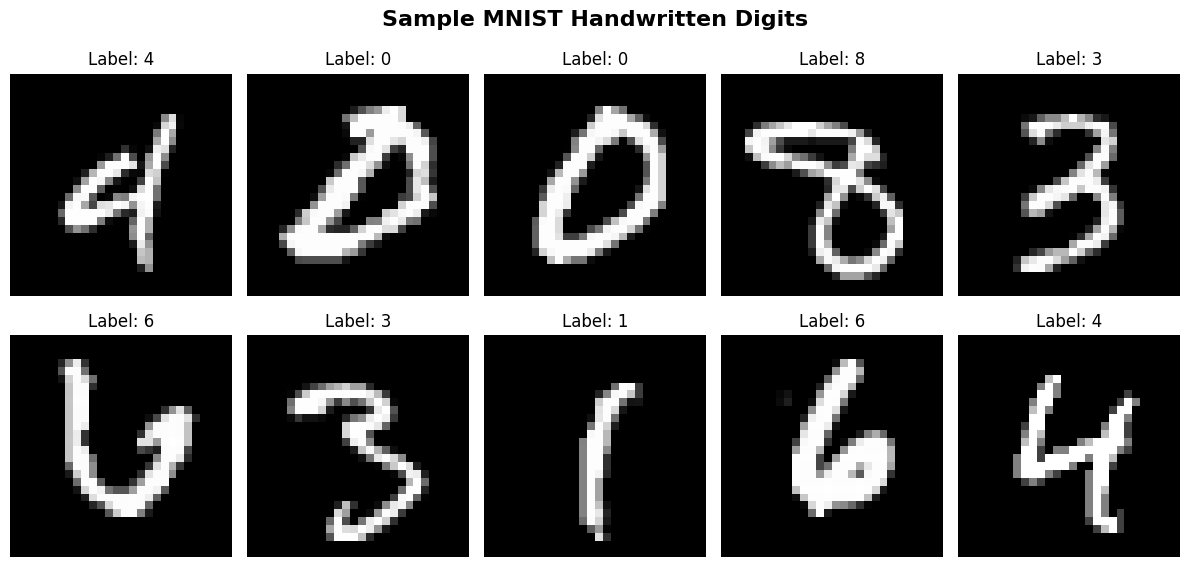

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

from tensorflow.keras.utils import to_categorical

X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

import tensorflow as tf

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax')


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,          # same as MLP (5 epochs)
    batch_size=BATCH_SIZE,  # same as MLP (128 batch size)
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)


# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)

# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Display Results
print(f"MLP Test Loss: {mlp_test_loss:.4f}")
print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f}")

print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")



MLP Test Loss: 0.0818
MLP Test Accuracy: 0.9728
CNN Test Loss: 0.0313
CNN Test Accuracy: 0.9902


Performance comparison visualization

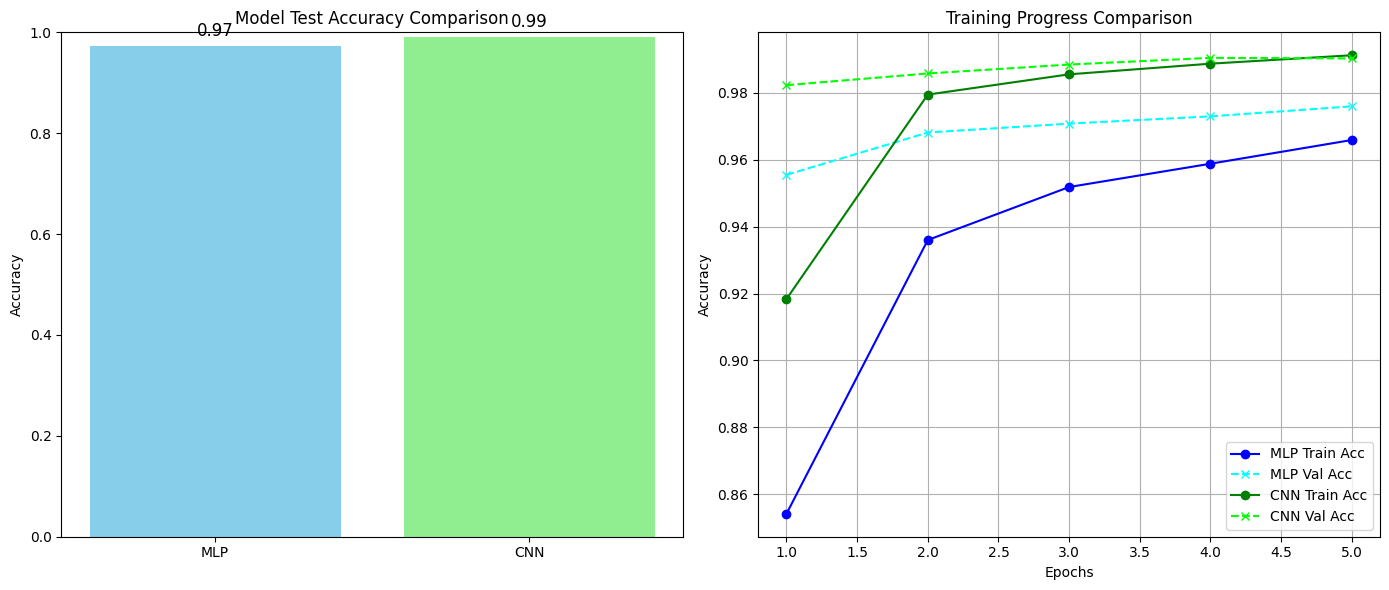

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

# Extract training history
mlp_train_acc = mlp_history.history['accuracy']
mlp_val_acc = mlp_history.history['val_accuracy']
cnn_train_acc = cnn_history.history['accuracy']
cnn_val_acc = cnn_history.history['val_accuracy']

mlp_train_loss = mlp_history.history['loss']
mlp_val_loss = mlp_history.history['val_loss']
cnn_train_loss = cnn_history.history['loss']
cnn_val_loss = cnn_history.history['val_loss']

# Final test accuracies (already computed earlier)
mlp_final_acc = mlp_test_accuracy
cnn_final_acc = cnn_test_accuracy


# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Bar chart for final test accuracy comparison ---
axes[0].bar(['MLP', 'CNN'], [mlp_final_acc, cnn_final_acc], color=['skyblue', 'lightgreen'])
axes[0].set_ylim(0, 1)
axes[0].set_title("Model Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
for i, acc in enumerate([mlp_final_acc, cnn_final_acc]):
    axes[0].text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=12)

# --- Right: Line plot for training progress comparison ---
epochs_range = range(1, EPOCHS + 1)

axes[1].plot(epochs_range, mlp_train_acc, label='MLP Train Acc', color='blue', marker='o')
axes[1].plot(epochs_range, mlp_val_acc, label='MLP Val Acc', color='cyan', linestyle='--', marker='x')
axes[1].plot(epochs_range, cnn_train_acc, label='CNN Train Acc', color='green', marker='o')
axes[1].plot(epochs_range, cnn_val_acc, label='CNN Val Acc', color='lime', linestyle='--', marker='x')

axes[1].set_title("Training Progress Comparison")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

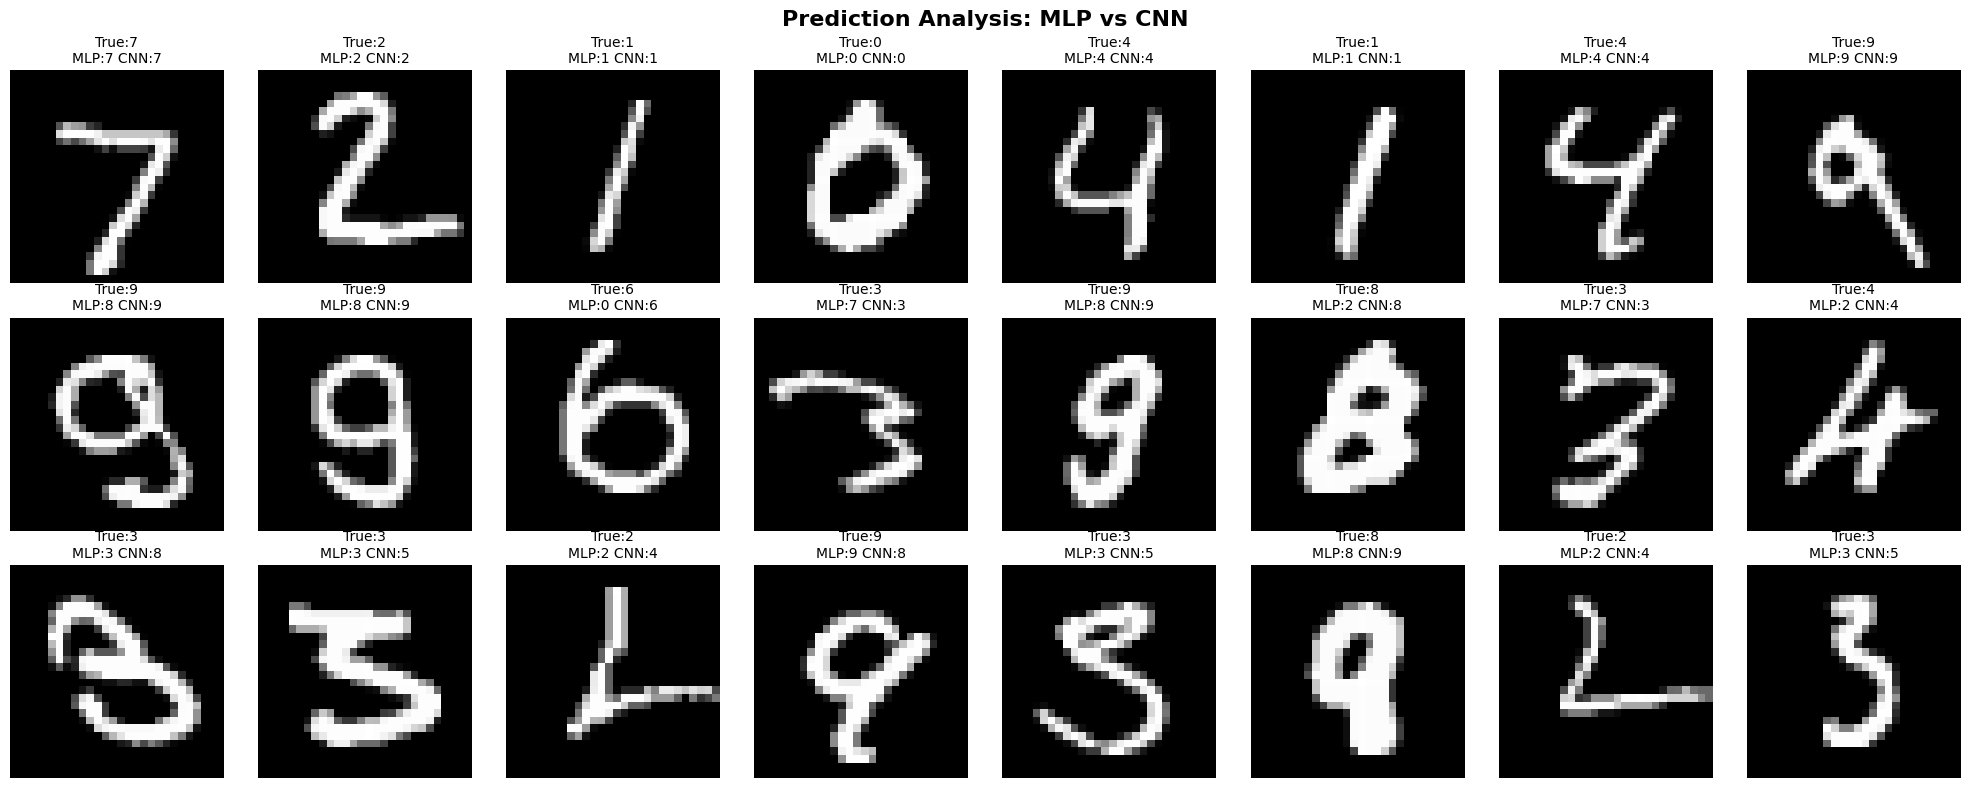

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle("Prediction Analysis: MLP vs CNN", fontsize=16, fontweight='bold')



# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
# CNN correct, MLP wrong
cnn_correct_mlp_wrong = (mlp_predicted_classes != y_test) & (cnn_predicted_classes == y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

# MLP correct, CNN wrong
mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]



# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)
# First row: Both models correct
for i, idx in enumerate(both_correct_indices):
    axes[0, i].imshow(X_test[idx], cmap='gray')
    axes[0, i].set_title(f"True:{y_test[idx]}\nMLP:{mlp_predicted_classes[idx]} CNN:{cnn_predicted_classes[idx]}", fontsize=10)
    axes[0, i].axis('off')

# Second row: CNN correct, MLP wrong
for i, idx in enumerate(cnn_correct_mlp_wrong_indices):
    axes[1, i].imshow(X_test[idx], cmap='gray')
    axes[1, i].set_title(f"True:{y_test[idx]}\nMLP:{mlp_predicted_classes[idx]} CNN:{cnn_predicted_classes[idx]}", fontsize=10)
    axes[1, i].axis('off')

# Third row: MLP correct, CNN wrong
for i, idx in enumerate(mlp_correct_cnn_wrong_indices):
    axes[2, i].imshow(X_test[idx], cmap='gray')
    axes[2, i].set_title(f"True:{y_test[idx]}\nMLP:{mlp_predicted_classes[idx]} CNN:{cnn_predicted_classes[idx]}", fontsize=10)
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answers here

**1. Which model performed better and why? (1 marks)**

CNN performed better with a test accuracy of 98.90% compared to the MLP’s 97.17%.

The reason is that CNNs preserve spatial relationships between pixels and learn local patterns (edges, curves, shapes) through convolutional filters, while MLPs treat each pixel independently. This makes CNNs more effective for image recognition tasks like MNIST.

**2. How do the training curves compare between the two models? (1 marks)**

MLP curves: Show steady improvement with slightly higher validation loss.

CNN curves: Achieve higher accuracy faster and maintain lower validation loss, indicating better generalization.

Overall, CNN training curves are smoother and show less overfitting compared to MLP.

**3. What does the accuracy improvement percentage tell us? (1 marks)**

Improvement = 98.90% − 97.17% = 1.73%.

It highlights CNN’s ability to capture spatial features that MLP misses, giving it an edge in real-world performance.

**4. Why didn't we need many epochs for good results? (1 marks)**

MNIST is a relatively simple dataset: grayscale, centered digits, low noise.

Both MLP and CNN can quickly learn distinguishing features (strokes, loops, angles).

With efficient optimizers like Adam, convergence happens fast, so even 5 epochs are enough to reach high accuracy.

**5. What would happen with more complex images? (1 marks)**

MLP performance would drop significantly because it cannot capture spatial hierarchies.

CNNs would scale better, as deeper convolutional layers can learn complex features (textures, objects, context).

More epochs, larger architectures, and techniques like data augmentation would be required to achieve strong results.